#### Import libraries and load the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Titanic-Dataset (1).csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


#### Explporatory Data Analysis

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### check for the distribution of the numeric columns

In [6]:
# Drop the passenger ID
df1 = df.drop(columns=['PassengerId'])

In [7]:
# view the numeric columns
numeric_cols = df1.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


#### visualize the distribution of the numeric columns

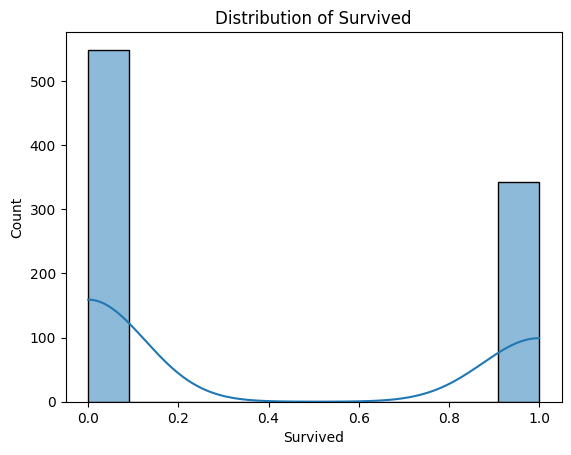

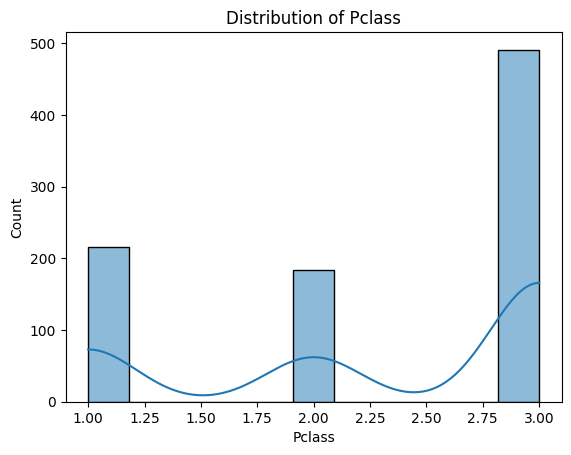

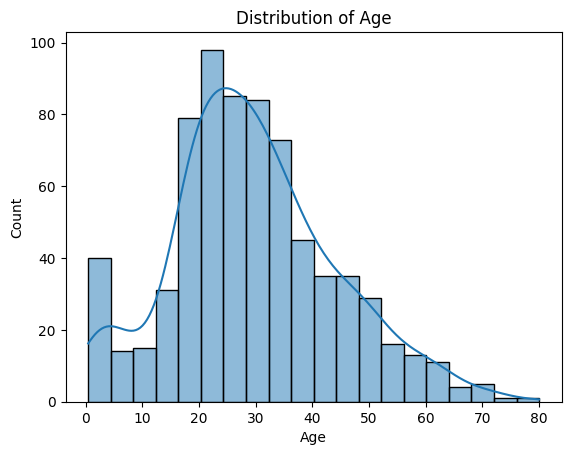

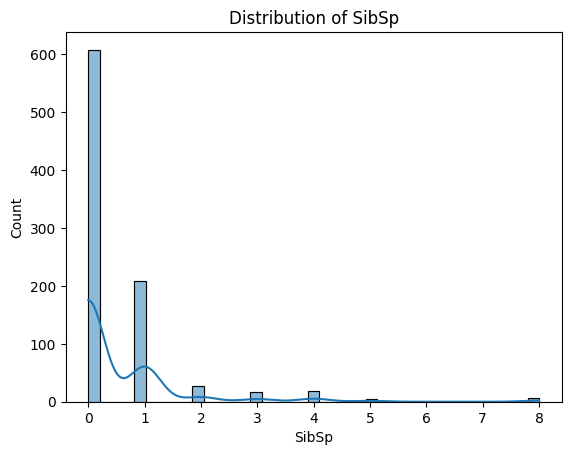

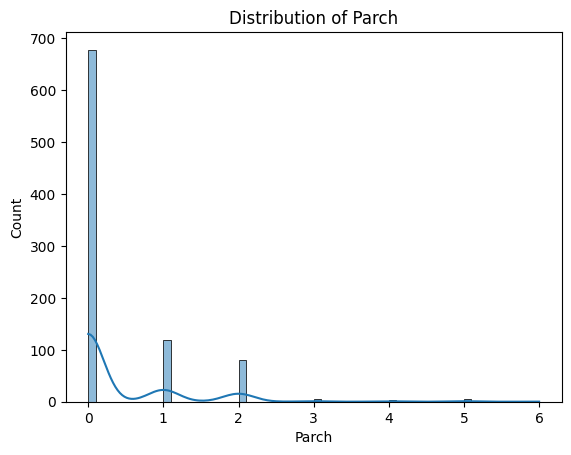

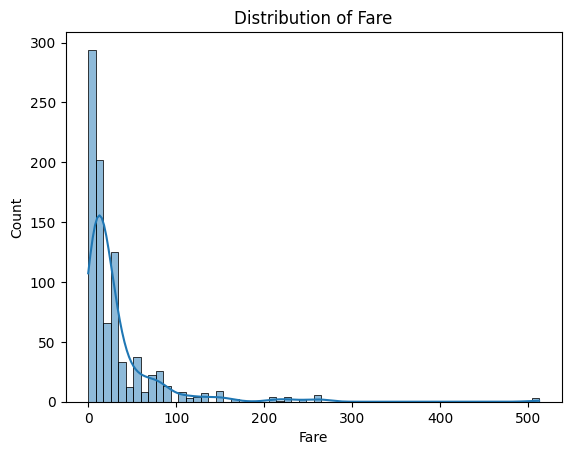

In [8]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df1[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#### Target Variable Analysis

In [9]:
df1['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

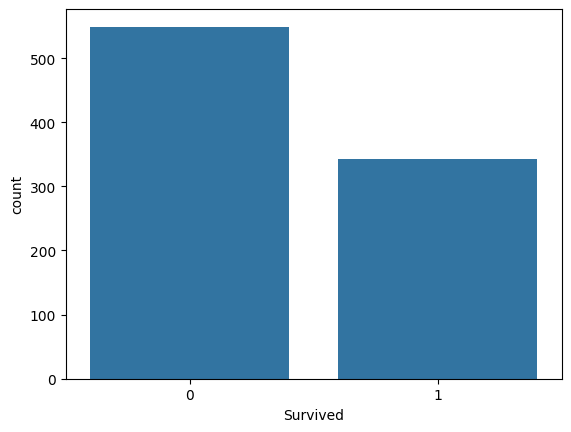

In [10]:
sns.countplot(x='Survived', data=df1)
plt.show()

##### Survival vs Gender

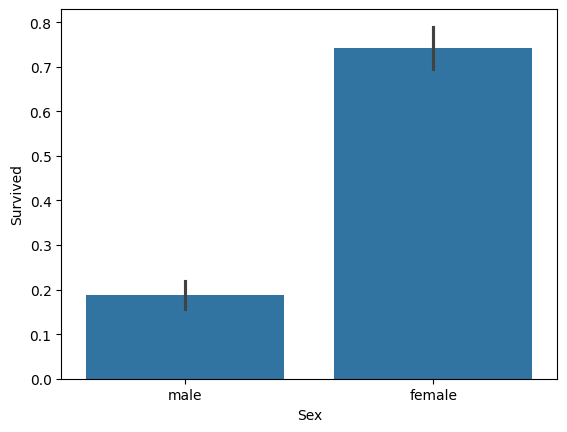

In [11]:
sns.barplot(x='Sex', y='Survived', data=df1)
plt.show()

#### Survival vs Passenger Class

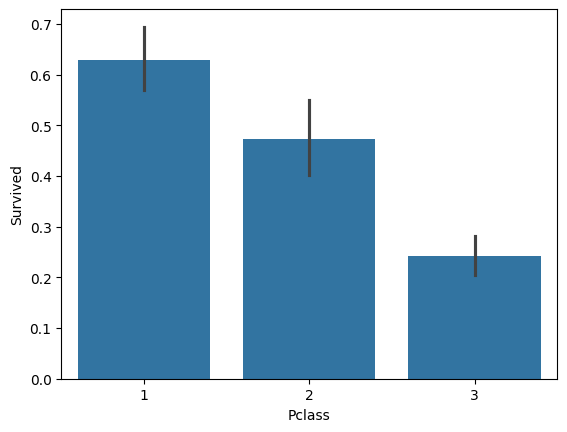

In [12]:
sns.barplot(x='Pclass', y='Survived', data=df1)
plt.show()

##### Age vs Survival

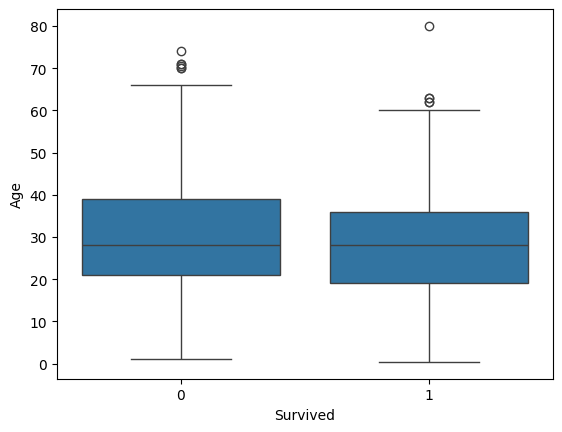

In [13]:
sns.boxplot(x='Survived', y='Age', data=df1)
plt.show()

##### Correlation Analysis

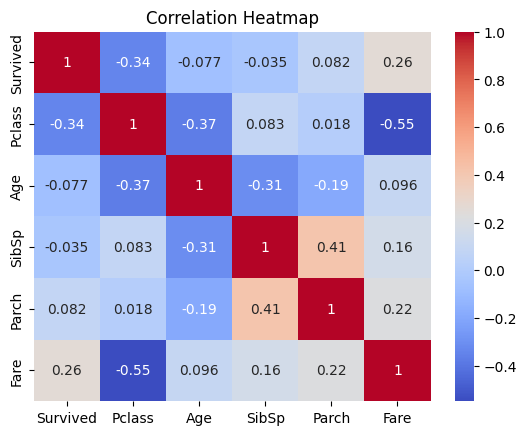

In [14]:
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Data Cleaning

#### Missing Value Analysis

In [15]:
df1.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [16]:
missing_percentage = df1.isnull().sum() / len(df1) * 100
print(missing_percentage)

Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


### visualize the missing values

In [17]:
import missingno as msno

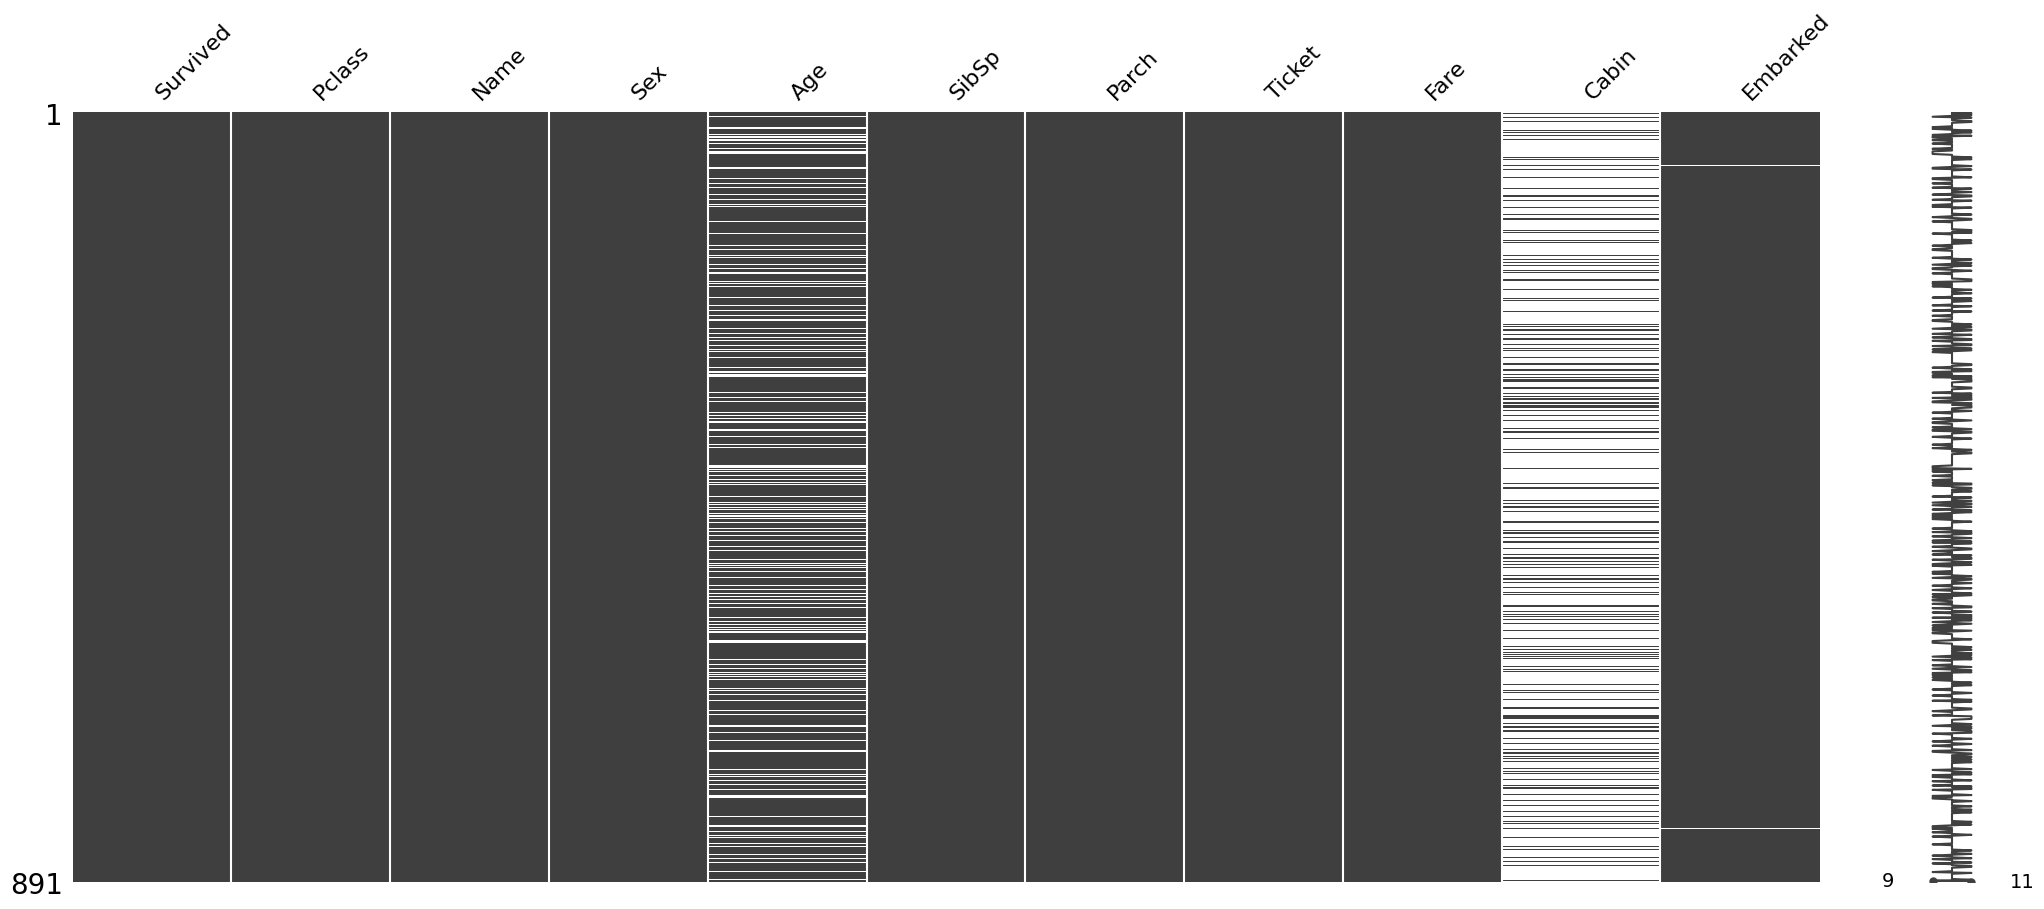

In [18]:
msno.matrix(df1)
plt.show()

#### Handle the missing values

In [19]:
# Drop the irrelevant columns
df2 = df1.drop(columns=['Name', 'Ticket', 'Cabin'])

# Age imputation
df2['Age'] = df2['Age'].fillna(df2['Age'].median())

# Embarked imputation
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

In [20]:
df2.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

#### Detect Outliers with Boxplot

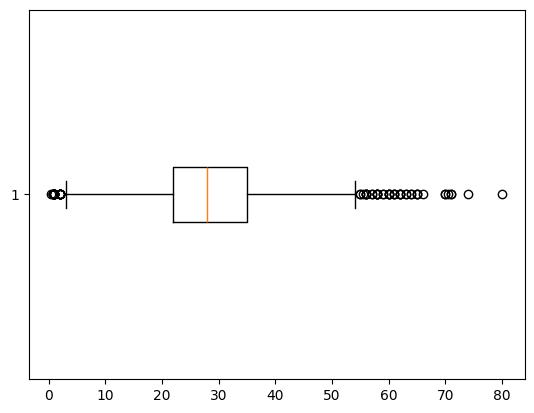

In [23]:
plt.boxplot(df2['Age'], vert=False)
plt.show()

#### Caculate the outlier boundary

In [24]:
# Compute Q1, Q3, and IQR
Q1 = df2['Age'].quantile(0.25)
Q3 = df2['Age'].quantile(0.75)
IQR = Q3 - Q1

In [25]:
# Define the boundaries for outliers
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR

In [26]:
# Filter out the outliers
df2_no_outliers = df2[(df2['Age'] >= lower_bound) & (df2['Age'] <= upper_bound)]

In [27]:
# check how many rows were removed
print("Before:", len(df2))
print("After:", len(df2_no_outliers))

Before: 891
After: 825


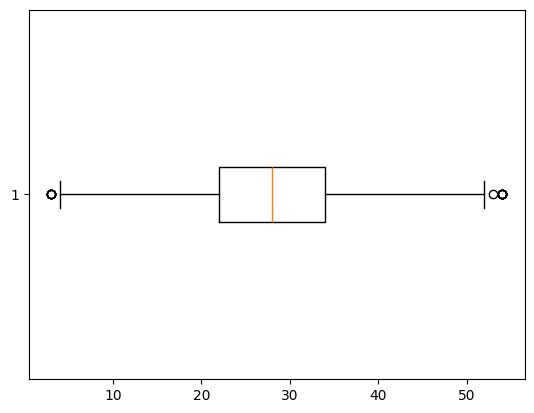

In [28]:
plt.boxplot(df2_no_outliers['Age'], vert=False)
plt.show()

In [29]:
df3 = df2_no_outliers.fillna(df2_no_outliers.median(numeric_only=True))
df3.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

#### Encoding

##### Identify the Cateogiral columns

In [30]:
cat_col = [col for col in df3.columns if df3[col].dtype == 'str']
print(cat_col)

['Sex', 'Embarked']


In [31]:
# count the unique values in each categorical column
df3[cat_col].nunique()

Sex         2
Embarked    3
dtype: int64

In [32]:
# Using one-hot encoding to convert categorical variables into numeric format
df4 = pd.get_dummies(df3, columns=cat_col, drop_first=True) 
df4.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [33]:
bool_cols = ['Sex_male', 'Embarked_Q', 'Embarked_S']
df4[bool_cols] = df4[bool_cols].astype(int)

In [34]:
df4.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

In [35]:
df4.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


### Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df4[['Age', 'SibSp', 'Parch']] = std_scaler.fit_transform(df4[['Age', 'SibSp', 'Parch']])
df4[['Fare']] = rob_scaler.fit_transform(df4[['Fare']].values.reshape(-1, 1))